In [117]:
from db import DB
from utils import *
import torch
import numpy as np
import torch.nn as nn
from torch.optim import lr_scheduler
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
from sklearn.preprocessing import MinMaxScaler
import akshare as ak
import pandas as pd
import talib


In [2]:
all_etfs = ak.fund_etf_fund_daily_em()

In [3]:
all_etfs = all_etfs["基金代码"].to_list()

In [9]:
all_etfs = pd.read_csv("all_etf.csv",names=["基金代码","类别","名称"])

In [13]:
all_etfs = all_etfs['基金代码'].astype(str).to_list()

In [19]:
for code in all_etfs:
    df = ak.fund_etf_hist_em(code)
    df.to_csv(f"{code}.csv",index=False)

In [43]:
def build_dataset(start_date, end_data):
    total_samples = []
    total_labels = []

    for code in all_etfs:
        samples = []
        labels = []
        df = pd.read_csv(f"{code}.csv")
        df = df.rename(columns={"日期": "date","开盘":"open","收盘":"close","最高":"high","最低":"low","成交量":"volume","成交额":"amount","换手率":"turn"})
        df['date'] = pd.to_datetime(df["date"])
        df.set_index(keys='date',inplace=True)
        df = df[["open", "high", "low", "close", "volume", "turn"]]

        df = df.loc[pd.to_datetime(start_date):pd.to_datetime(end_data)]
        print(df)

        df = df.dropna()

        num_samples = len(df)
        if num_samples < 180:
            continue

        for i in range(num_samples - 80):
            sample = df.iloc[i : i + 60]
            future_slice = df.iloc[i + 60 : i + 80]
            change_percentage = (
                (np.mean(future_slice["low"]) - sample["close"].iloc[-1])
                / sample["close"].iloc[-1]
            ) * 100
            if not np.isnan(change_percentage):
                scaler = MinMaxScaler()
                normalized_data = scaler.fit_transform(sample.values)
                samples.append(normalized_data)
                labels.append(change_percentage)

        total_samples.extend(samples)
        total_labels.extend(labels)
    
    scaler = MinMaxScaler()
    total_labels = scaler.fit_transform(np.array(total_labels).reshape(-1, 1)).flatten()
    
    feature = torch.tensor(np.array(total_samples), dtype=torch.float32)
    labels = torch.tensor(np.array(total_labels), dtype=torch.float32)

    return TensorDataset(feature, labels)


In [ ]:
build_dataset("20230101", "20250101")

             open   high    low  close    volume  turn
date                                                  
2020-11-16  1.556  1.620  1.451  1.465  14453638  1.98
2020-11-17  1.460  1.460  1.430  1.436  10806365  1.48
2020-11-18  1.435  1.445  1.422  1.424   8631881  1.18
2020-11-19  1.424  1.440  1.412  1.438   6854018  0.94
2020-11-20  1.436  1.444  1.431  1.435   6010034  0.82
...           ...    ...    ...    ...       ...   ...
2024-12-25  1.072  1.080  1.064  1.072  41294421  5.65
2024-12-26  1.070  1.085  1.066  1.081  38092005  5.21
2024-12-27  1.080  1.099  1.071  1.074  46749628  6.39
2024-12-30  1.070  1.087  1.066  1.077  32162599  4.40
2024-12-31  1.076  1.078  1.043  1.045  46362003  6.34

[1003 rows x 6 columns]
             open   high    low  close    volume  turn
date                                                  
2020-01-02  1.900  1.901  1.878  1.895    944916  0.15
2020-01-03  1.895  1.898  1.880  1.887    464989  0.07
2020-01-06  1.878  1.886  1.856  1.867  

KeyboardInterrupt: 

In [45]:
class LeNet(nn.Module):  # 继承于nn.Module这个父类
    def __init__(self):  # 初始化网络结构
        super(LeNet, self).__init__()  # 多继承需用到super函数
        self.conv1 = nn.Conv2d(1, 16, 5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 1)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        self.fc1 = nn.Linear(32 * 14 * 1, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 1)
        self.relu = nn.ReLU()

    def forward(self, x):  # 正向传播过程
        x = x.unsqueeze(1)
        x = self.relu(self.conv1(x))  # input(1, 60, 6) output(16, 28, 28)
        x = self.pool1(x)  # output(16, 52, 2)
        x = self.relu(self.conv2(x))  # output(32, 28, 1)
        x = self.pool2(x)  # output(32, 14, 1)
        x = x.view(-1, 32 * 14 * 1)  # output(32*14*1)
        x = self.relu(self.fc1(x))  # output(120)
        x = self.relu(self.fc2(x))  # output(84)
        x = self.fc3(x)  # output(1)
        return x


In [46]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, num_epochs, device, writer):
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        model.train()
        for i, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)
            output = model(x).squeeze(1)
            loss = criterion(output, y)
            epoch_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()
        writer.add_scalar("Loss/train", epoch_loss / len(train_loader), epoch)

        with torch.no_grad():
            model.eval()
            valid_loss = 0.0
            for x, y in valid_loader:
                x = x.to(device)
                y = y.to(device)
                output = model(x).squeeze(1)
                loss = criterion(output, y)
                valid_loss += loss.item()
            print(
                f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {epoch_loss / len(train_loader)} Valid Loss: {valid_loss / len(valid_loader)}"
            )
            writer.add_scalar("Loss/valid", valid_loss / len(valid_loader), epoch)

    return model

In [69]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
num_epochs=100
batch_size=64
learning_rate=0.0001

In [70]:
model = LeNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [71]:
train_dataset = build_dataset("20100101", "20230101")
valid_dataset = build_dataset("20230101", "20250101")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


             open   high    low  close    volume  turn
date                                                  
2020-11-16  1.556  1.620  1.451  1.465  14453638  1.98
2020-11-17  1.460  1.460  1.430  1.436  10806365  1.48
2020-11-18  1.435  1.445  1.422  1.424   8631881  1.18
2020-11-19  1.424  1.440  1.412  1.438   6854018  0.94
2020-11-20  1.436  1.444  1.431  1.435   6010034  0.82
...           ...    ...    ...    ...       ...   ...
2022-12-26  0.961  0.993  0.960  0.992  20697596  2.83
2022-12-27  0.994  1.007  0.987  1.004  17568542  2.40
2022-12-28  0.999  1.004  0.996  0.998  11521170  1.58
2022-12-29  0.994  1.011  0.993  1.004  15721922  2.15
2022-12-30  1.005  1.011  1.000  1.003  11055558  1.51

[519 rows x 6 columns]
             open   high    low  close    volume  turn
date                                                  
2013-10-28  0.970  0.970  0.958  0.959    683645  0.11
2013-10-29  0.957  0.970  0.930  0.950    321853  0.05
2013-10-30  0.950  0.965  0.950  0.962   

In [55]:
print(len(train_dataset))

30465


In [72]:
from torch.utils.tensorboard import SummaryWriter
from sklearn.preprocessing import MinMaxScaler

writer = SummaryWriter()

In [73]:
best_loss = float("inf")

for epoch in range(num_epochs):
        epoch_loss = 0.0
        model.train()
        for i, (x, y) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)
            output = model(x).squeeze(1)
            loss = criterion(output, y)
            epoch_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()
        writer.add_scalar("Loss/train", epoch_loss / len(train_loader), epoch)

        with torch.no_grad():
            model.eval()
            valid_loss = 0.0
            for x, y in valid_loader:
                x = x.to(device)
                y = y.to(device)
                output = model(x).squeeze(1)
                loss = criterion(output, y)
                valid_loss += loss.item()
            print(
                f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {epoch_loss / len(train_loader)} Valid Loss: {valid_loss / len(valid_loader)}"
            )

            if valid_loss < best_loss:
                torch.save(model,"etf.pth")
            writer.add_scalar("Loss/valid", valid_loss / len(valid_loader), epoch)

Epoch 1/100, Train Loss: 0.04700626947664323 Valid Loss: 0.16161418271561465
Epoch 2/100, Train Loss: 0.002444131724604511 Valid Loss: 0.16626834941024965
Epoch 3/100, Train Loss: 0.002357802102611016 Valid Loss: 0.16208281592489818
Epoch 4/100, Train Loss: 0.002314845120057901 Valid Loss: 0.15604669285508302
Epoch 5/100, Train Loss: 0.002281879063138677 Valid Loss: 0.1640610191015861
Epoch 6/100, Train Loss: 0.0022450081772642967 Valid Loss: 0.1596896395755884
Epoch 7/100, Train Loss: 0.0022298350143861376 Valid Loss: 0.1664178223373034
Epoch 8/100, Train Loss: 0.0022188801867265183 Valid Loss: 0.16458058978120485
Epoch 9/100, Train Loss: 0.0022071356592720235 Valid Loss: 0.1620288348923891
Epoch 10/100, Train Loss: 0.002198887439678961 Valid Loss: 0.16434076547813722
Epoch 11/100, Train Loss: 0.002199307101655681 Valid Loss: 0.15782748215282574
Epoch 12/100, Train Loss: 0.002188513751373093 Valid Loss: 0.1590639964605753
Epoch 13/100, Train Loss: 0.0021840016626917895 Valid Loss: 0.1

In [94]:

model = torch.load("etf.pth",weights_only=False)


In [109]:
test_dataset = []
names = []
for code in all_etfs:
    df = pd.read_csv(f"{code}.csv")
    df = df.rename(columns={"日期": "date","开盘":"open","收盘":"close","最高":"high","最低":"low","成交量":"volume","成交额":"amount","换手率":"turn"})
    df['date'] = pd.to_datetime(df["date"])
    df.set_index(keys='date',inplace=True)
    df = df[["open", "high", "low", "close", "volume", "turn"]]
    e = -20
    df = df.iloc[e-60:e]
    print(df)
    scaler = MinMaxScaler()
    normalized_data = scaler.fit_transform(df)
    normalized_df = pd.DataFrame(normalized_data, columns=df.columns)
    test_dataset.append(normalized_df.values)
    names.append(code)

             open   high    low  close    volume   turn
date                                                   
2024-12-23  1.065  1.080  1.050  1.052  43811656   5.99
2024-12-24  1.056  1.071  1.045  1.069  38451008   5.26
2024-12-25  1.072  1.080  1.064  1.072  41294421   5.65
2024-12-26  1.070  1.085  1.066  1.081  38092005   5.21
2024-12-27  1.080  1.099  1.071  1.074  46749628   6.39
2024-12-30  1.070  1.087  1.066  1.077  32162599   4.40
2024-12-31  1.076  1.078  1.043  1.045  46362003   6.34
2025-01-02  1.041  1.042  0.997  1.009  68852492   9.41
2025-01-03  1.009  1.015  0.992  0.993  47231679   6.46
2025-01-06  0.995  1.001  0.981  0.989  36017745   4.92
2025-01-07  0.991  1.019  0.987  1.018  48389145   6.62
2025-01-08  1.010  1.029  0.988  1.017  48609297   6.65
2025-01-09  1.013  1.025  1.012  1.015  32602934   4.46
2025-01-10  1.013  1.034  1.004  1.005  46573206   6.37
2025-01-13  0.990  1.009  0.990  1.005  30627031   4.19
2025-01-14  1.012  1.039  1.000  1.037  54575248

In [110]:
DATA = np.stack(test_dataset, axis=0)
DATA = torch.tensor(DATA, dtype=torch.float32)
print(DATA.shape)
dataset_test = TensorDataset(DATA)
test_loader = DataLoader(dataset_test, shuffle=False, batch_size=50)

torch.Size([25, 60, 6])


In [111]:
S=[]

In [112]:
model.eval()
with torch.no_grad():
    for x in test_loader:
        x[0] = x[0].to(device)
        output = model(x[0])
        S.extend(output.cpu().numpy())

In [113]:
# 创建 DataFrame
df = pd.DataFrame({'name': names, '打分': S})
df['打分'] = df['打分'].apply(lambda x: x[0] if x else None)
# 获取打分最高的 10 个 name
top_10_names = df.nlargest(10, '打分')

In [114]:
top_10_names

,name,打分
14,515880,0.784037
16,512800,0.776407
0,588000,0.774601
13,512660,0.770421
15,515030,0.767688
6,159995,0.767152
9,159949,0.763613
8,510300,0.762492
18,510880,0.761199
23,159509,0.755638


In [116]:
ma = {}

In [134]:

for code in all_etfs:
    df = pd.read_csv(f"{code}.csv")
    df = df.rename(columns={"日期": "date","开盘":"open","收盘":"close","最高":"high","最低":"low","成交量":"volume","成交额":"amount","换手率":"turn"})
    df['date'] = pd.to_datetime(df["date"])
    df.set_index(keys='date',inplace=True)
    df = df[["open", "high", "low", "close", "volume", "turn"]]
    df = df.iloc[-150:]
    m5 = talib.SMA(df['close'],5)
    ma[f'{code}'] = m5
    ma=pd.DataFrame(ma)
    ma = ma.dropna()
    ma = ma / ma.iloc[0]

ma

,510880,515880,588000,512010,513050,512880,159941,510050,159995,513060,...,512660,515030,512800,512980,159869,159819,159870,159611,159509,518880
date,,,,,,,,,,,,,,,,,,,,,
2024-09-11,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2024-09-12,0.991360,1.000402,0.995683,0.993051,0.997193,0.999256,1.008395,0.994426,0.994615,1.000581,...,0.996572,0.999784,0.994898,0.996592,0.997410,0.999030,0.994769,0.990632,1.010120,1.001053
2024-09-13,0.983818,1.008245,0.991942,0.989261,0.995990,0.998264,1.017181,0.989366,0.990000,1.005814,...,0.994368,0.997408,0.988479,0.993183,0.993784,1.001616,0.990744,0.982968,1.023113,1.004464
2024-09-18,0.982309,1.014076,0.989353,0.984839,0.997394,0.997768,1.026552,0.988080,0.984103,1.011047,...,0.992899,0.996544,0.988150,0.989775,0.988345,1.005495,0.988732,0.977645,1.030908,1.009256
2024-09-19,0.979978,1.016489,0.986763,0.983575,1.005413,1.000496,1.036704,0.987908,0.978974,1.018023,...,0.990206,0.997840,0.986669,0.987389,0.986014,1.007111,0.991952,0.974452,1.044858,1.012413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-17,1.048889,1.129298,1.526906,1.100442,1.283881,1.273810,1.037485,1.156505,1.596667,1.314535,...,1.236533,1.251026,1.245392,1.323790,1.356384,1.425016,1.096177,1.014477,0.929841,1.342710
2025-04-18,1.052592,1.131510,1.526331,1.099179,1.284082,1.273810,1.032995,1.160192,1.594103,1.316279,...,1.230167,1.249082,1.255267,1.328221,1.363636,1.423723,1.093360,1.017032,0.925191,1.353962
2025-04-21,1.053689,1.133722,1.528058,1.097915,1.282678,1.275298,1.024600,1.162422,1.594872,1.309302,...,1.227473,1.251242,1.260533,1.335378,1.374255,1.426955,1.091751,1.017884,0.914661,1.368371


<Axes: xlabel='date'>

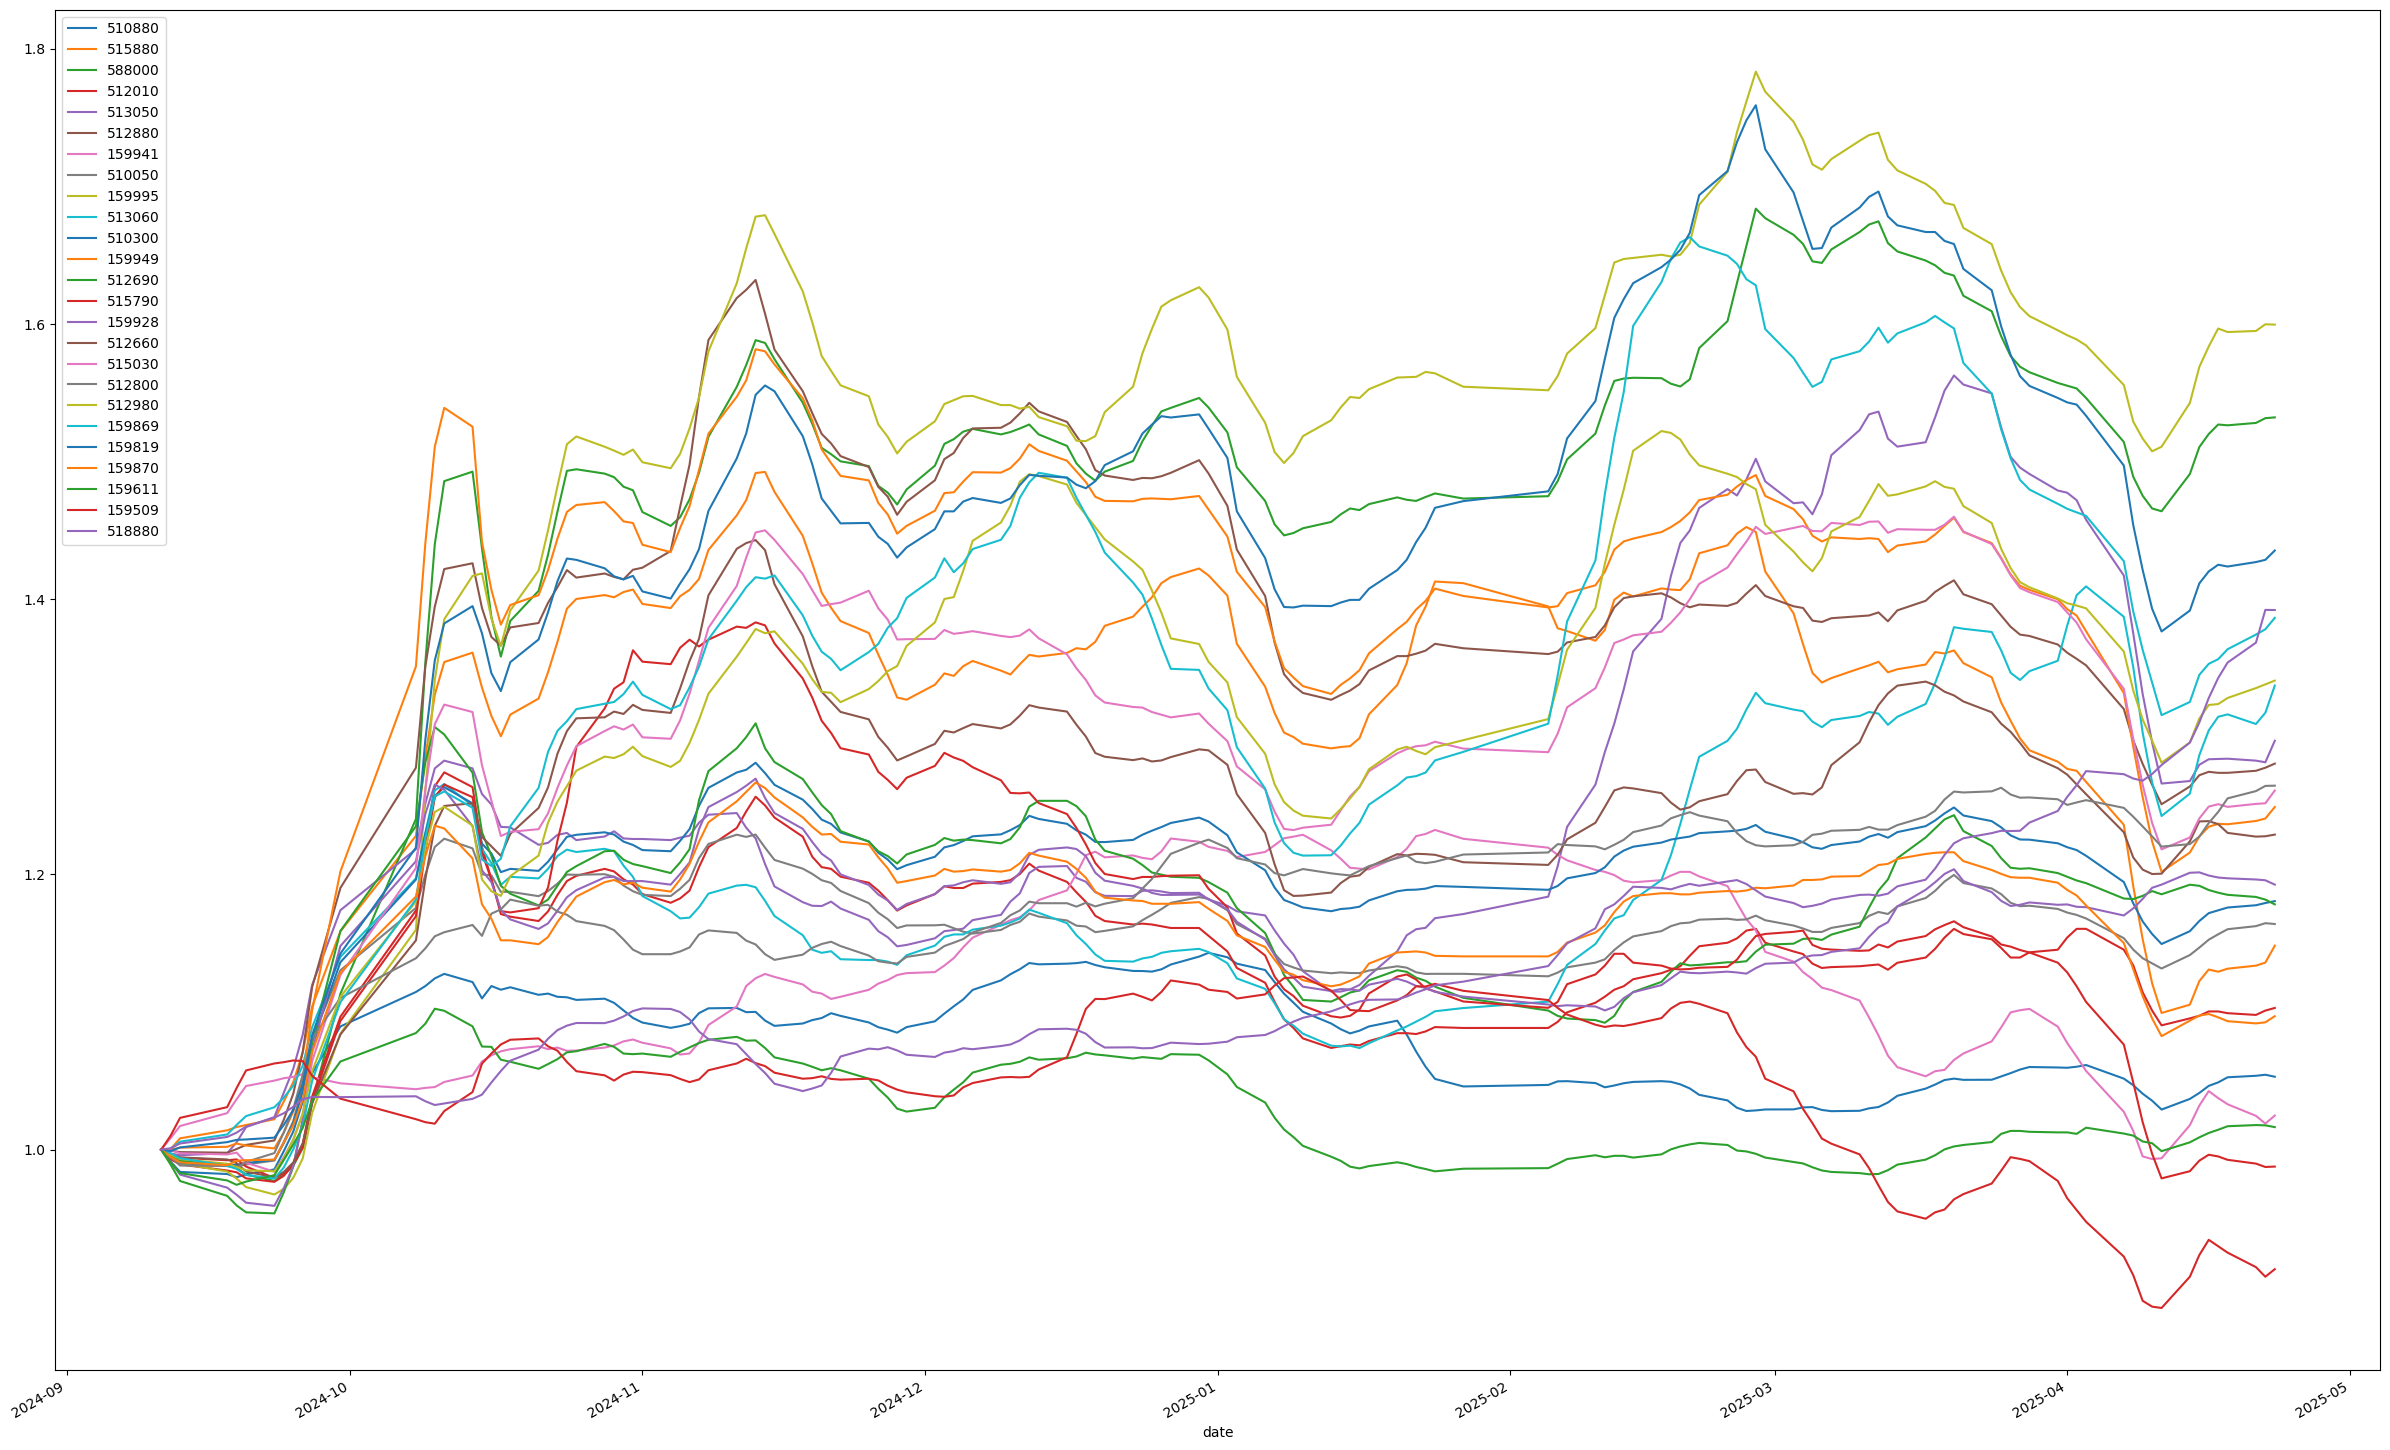

In [138]:
ma.plot(figsize=(30,20))

In [122]:
import matplotlib.pyplot as plt
import random

In [ ]:
all_trd = {}

style = ['-','--','-.',':']
mark = '.,ov^<>12348spP*hH+xXDd|_'
fig = plt.figure((26,10))

plt.legend(loc='upper left')
plt.grid(which='major')
plt.title("90日走势")
plt.xticks(rotation=90, ha='center')
plt.show()

NameError: name 'figsize' is not defined